In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [60]:
df = pd.read_csv("Student_Performance_Dataset.csv")

In [61]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


# Exploratory Data Analysis (EDA)

**Definition:**  
Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset before applying any machine learning or statistical modeling. It helps to find patterns, detect anomalies, and decide how to preprocess the data.

---

## Key Steps in EDA

1. **Understand the Data Structure**
   - Check columns, data types, and number of rows/columns.
   - Example (Python): `df.info()`, `df.describe()`

2. **Handle Missing or Duplicate Data**
   - Identify missing values and decide whether to remove or fill them.
   - Example: `df.isnull().sum()`

3. **Summary Statistics**
   - Mean, median, mode, standard deviation, min, max.
   - Helps understand distributions and outliers.

4. **Data Visualization**
   - **Histograms** → Distribution of single variables  
   - **Box Plots** → Detect outliers  
   - **Scatter Plots** → Relationships between two variables  
   - **Heatmaps** → Correlation between variables

5. **Feature Engineering**
   - Creating, transforming, or selecting features from raw data to improve model performance.
---

## Purpose of EDA

- Find patterns, trends, and relationships in data.  
- Detect anomalies or missing values.  
- Decide which features to use in machine learning.  
- Improve model performance by preprocessing the data properly.


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

In [63]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


In [64]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Class                         0
Study_Hours_Per_Day           0
Attendance_Percentage         0
Parental_Education            0
Internet_Access               0
Extracurricular_Activities    0
Math_Score                    0
Science_Score                 0
English_Score                 0
Previous_Year_Score           0
Final_Percentage              0
Performance_Level             0
Pass_Fail                     0
dtype: int64

In [65]:
df["Math_Score"].mean()

67.7548

In [66]:
df["Science_Score"].mean()

66.8954

In [67]:
df["English_Score"].mean()

67.7828

In [68]:
 df.groupby('Class')[['Math_Score', 'English_Score']].mean()

,Math_Score,English_Score
Class,,
9,68.315271,67.878489
10,67.971560,67.877018
11,67.432647,67.794770
12,67.296965,67.574241


In [69]:
 df.groupby('Parental_Education')[['Math_Score', 'English_Score','Science_Score']].mean()

,Math_Score,English_Score,Science_Score
Parental_Education,,,
Graduate,67.863335,67.737508,66.752559
High School,67.675904,68.192771,66.851205
Postgraduate,67.725432,67.422275,67.080405


In [70]:
df['Math_Score'].std()

18.72448659482138

In [71]:
df['Total_Score'] = (df['Math_Score'] + df['English_Score'] + df['Science_Score'])/3

In [72]:
df['Total_Score']

0       50.333333
1       53.000000
2       71.666667
3       64.333333
4       41.000000
          ...    
4995    64.666667
4996    48.666667
4997    72.666667
4998    57.333333
4999    69.666667
Name: Total_Score, Length: 5000, dtype: float64

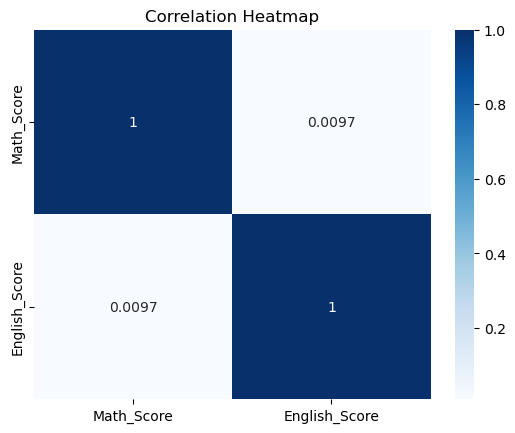

In [73]:
corr = df[['Math_Score', 'English_Score']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [74]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Study_Hours_Per_Day'], df['Total_Score'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.012962812248030458
P-value: 0.35944740135462633


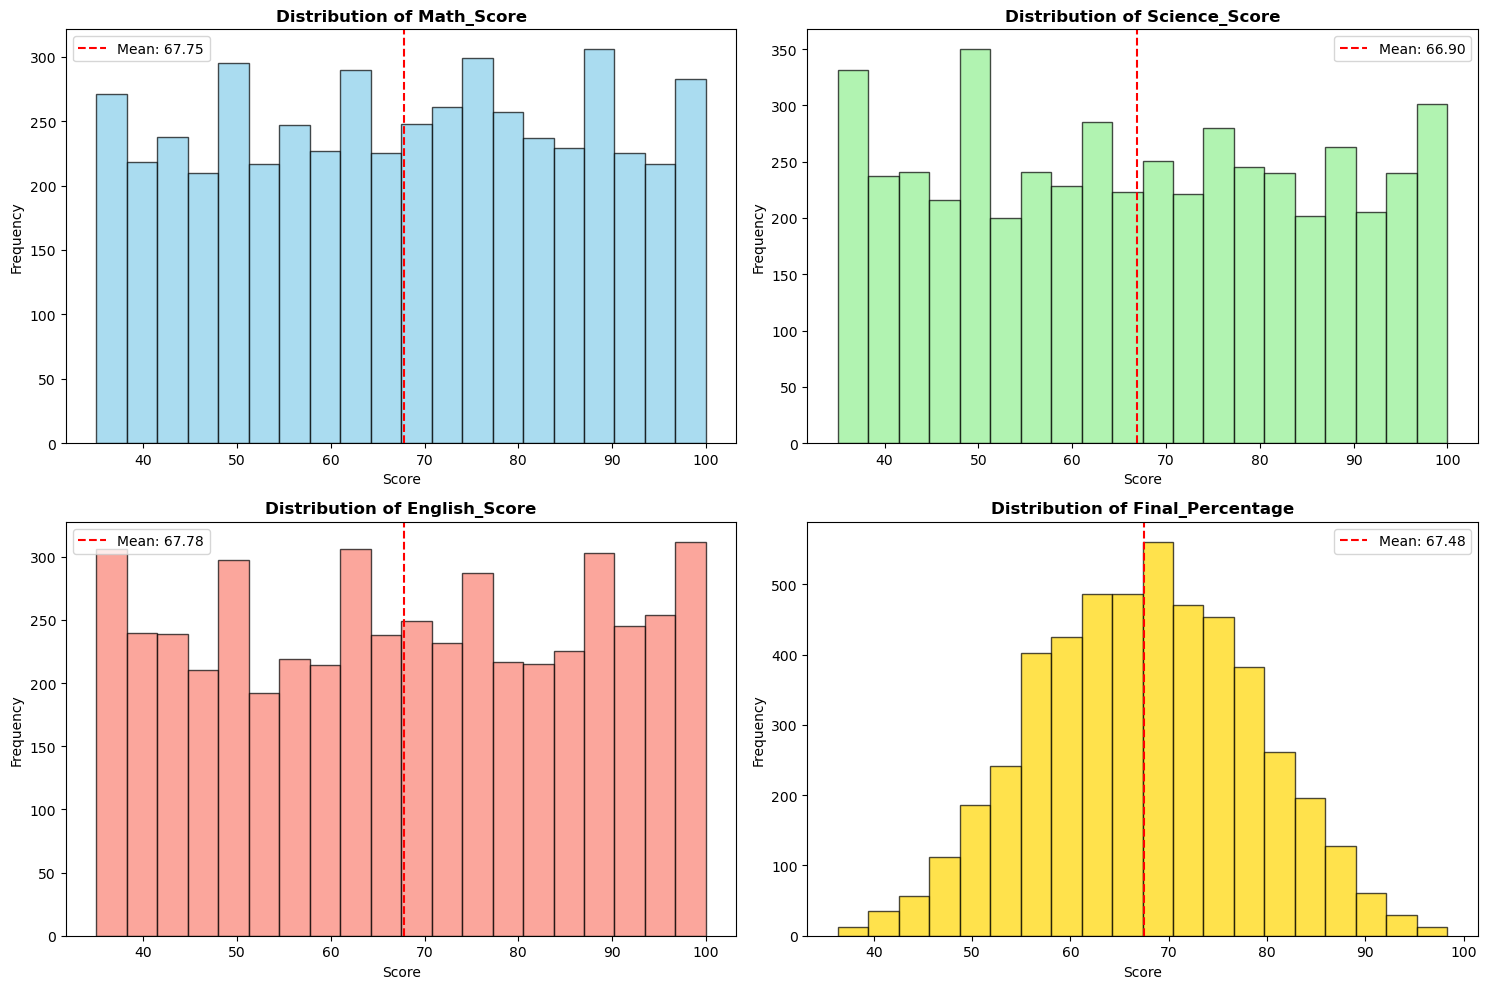

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
scores = ['Math_Score', 'Science_Score', 'English_Score', 'Final_Percentage']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']

for idx, (score, color) in enumerate(zip(scores, colors)):
    ax = axes[idx//2, idx%2]
    ax.hist(df[score], bins=20, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {score}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(df[score].mean(), color='red', linestyle='--', label=f'Mean: {df[score].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()


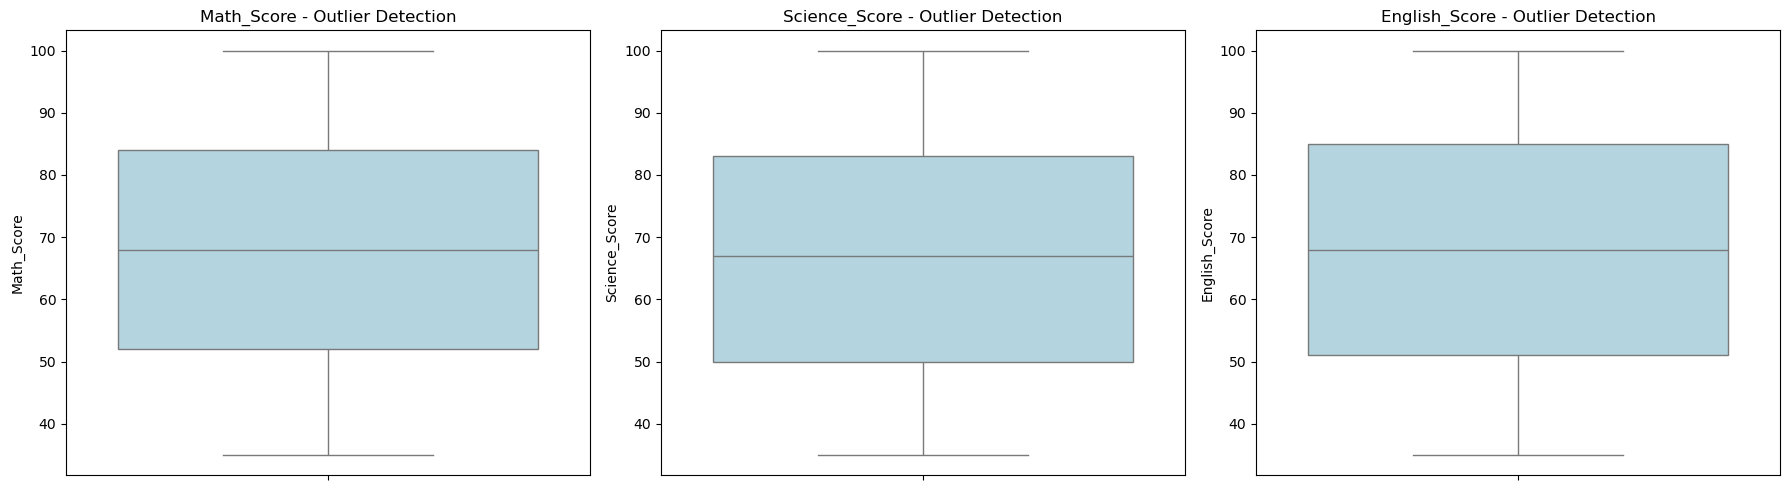

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scores = ['Math_Score', 'Science_Score', 'English_Score']

for idx, score in enumerate(scores):
    sns.boxplot(data=df, y=score, ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'{score} - Outlier Detection')
    
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

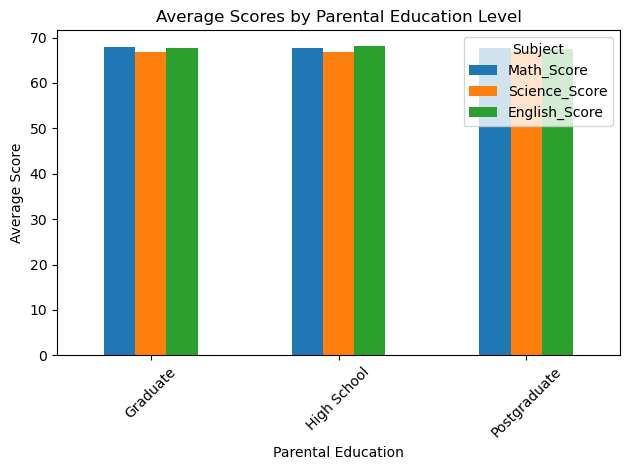

In [77]:
plt.figure(figsize=(12, 6))
df.groupby('Parental_Education')[['Math_Score', 'Science_Score', 'English_Score']].mean().plot(kind='bar')
plt.title('Average Scores by Parental Education Level')
plt.xlabel('Parental Education')
plt.ylabel('Average Score')
plt.legend(title='Subject')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

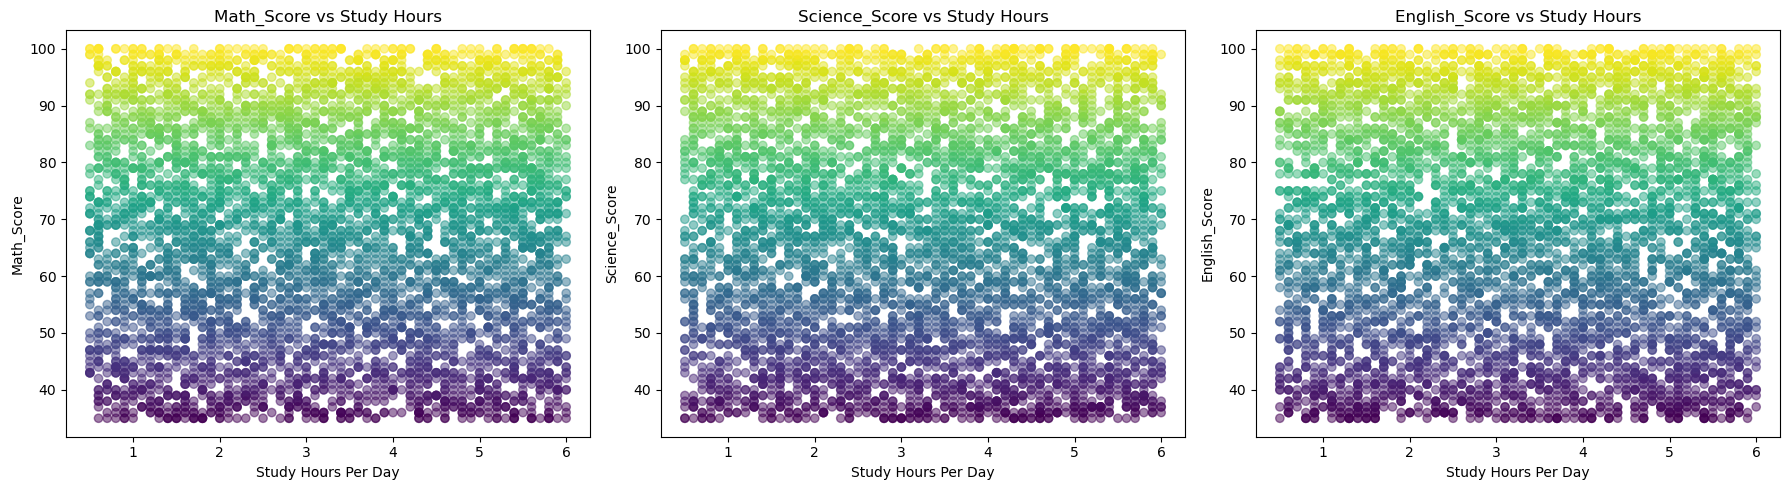

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, score in enumerate(['Math_Score', 'Science_Score', 'English_Score']):
    axes[idx].scatter(df['Study_Hours_Per_Day'], df[score], alpha=0.5, c=df[score], cmap='viridis')
    axes[idx].set_xlabel('Study Hours Per Day')
    axes[idx].set_ylabel(score)
    axes[idx].set_title(f'{score} vs Study Hours')
    
plt.tight_layout()
plt.show()

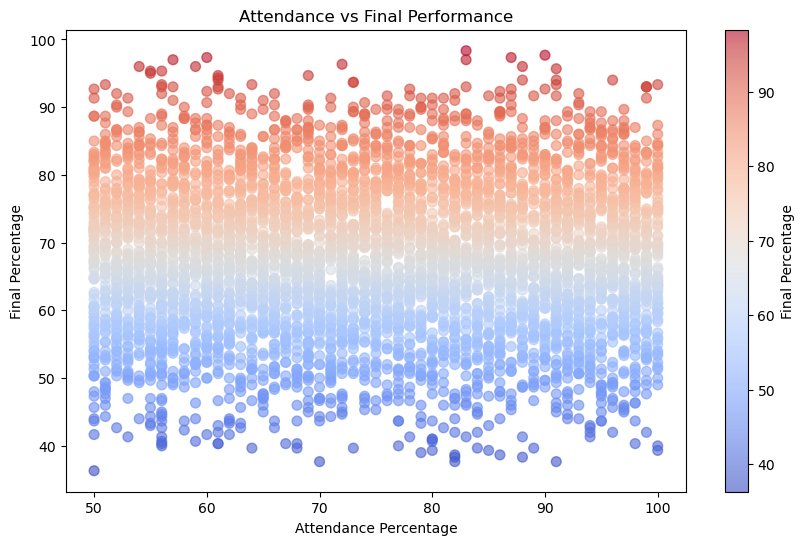

In [79]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Attendance_Percentage'], df['Final_Percentage'], 
            c=df['Final_Percentage'], cmap='coolwarm', alpha=0.6, s=50)
plt.colorbar(label='Final Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Final Percentage')
plt.title('Attendance vs Final Performance')
plt.show()

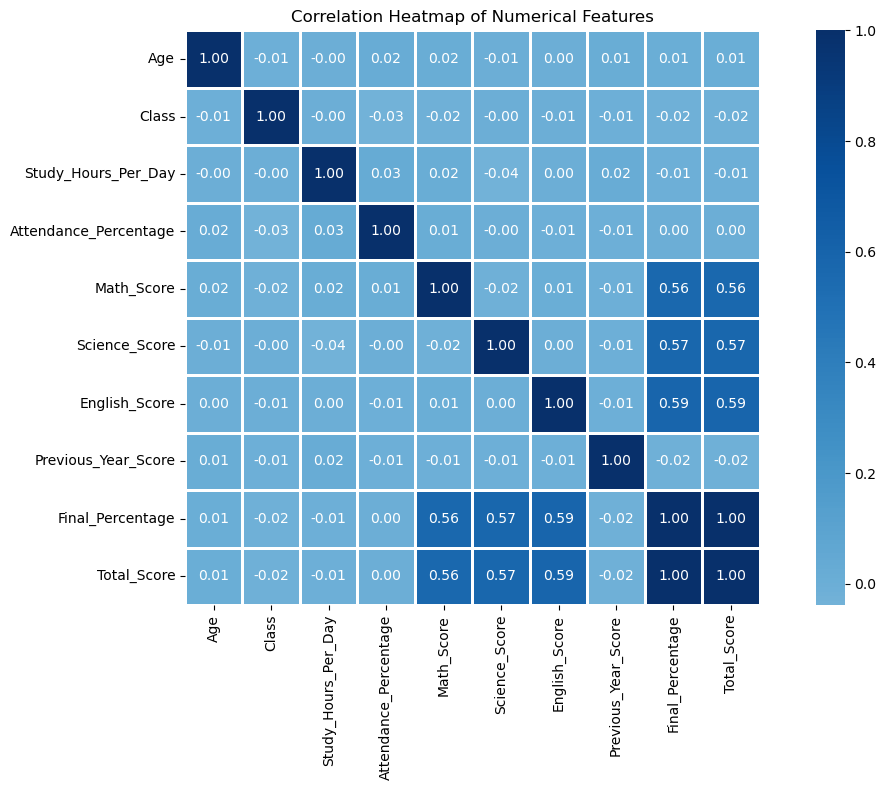

In [80]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='Blues', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

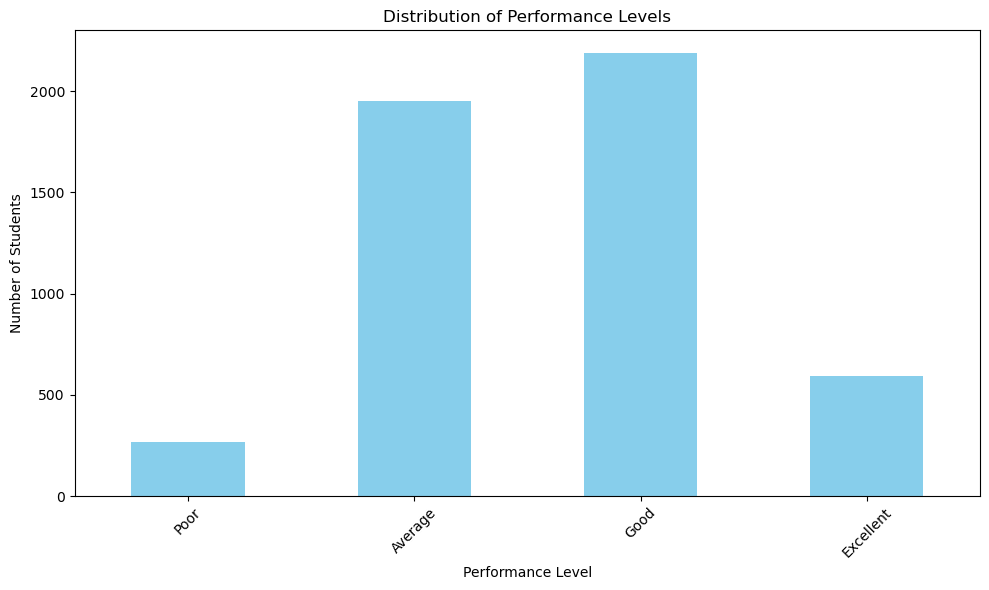

In [81]:
plt.figure(figsize=(10, 6))
performance_order = ['Poor', 'Average', 'Good', 'Excellent']
df['Performance_Level'].value_counts()[performance_order].plot(kind='bar', color='skyblue')
plt.title('Distribution of Performance Levels')
plt.xlabel('Performance Level')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

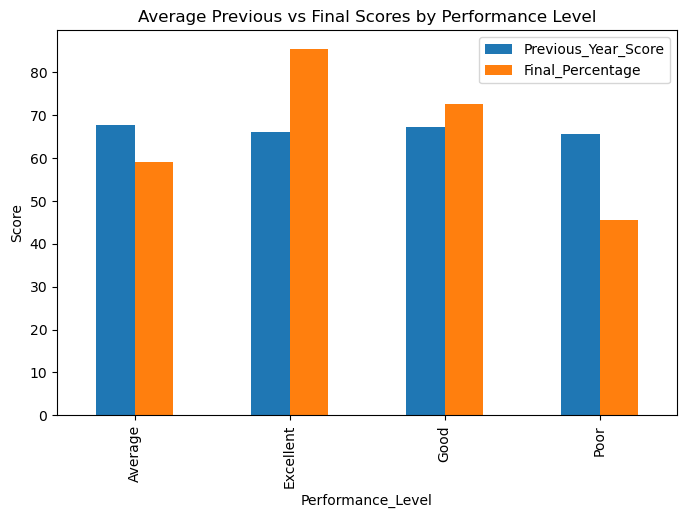

In [102]:
df.groupby('Performance_Level')[['Previous_Year_Score', 'Final_Percentage']].mean().plot(
    kind='bar', figsize=(8,5)
)
plt.title("Average Previous vs Final Scores by Performance Level")
plt.ylabel("Score")
plt.show()

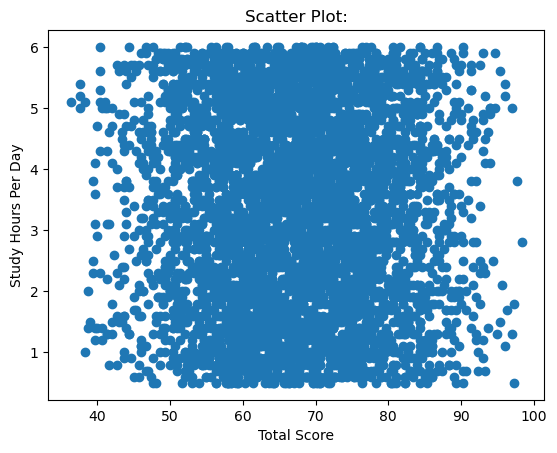

In [82]:
plt.scatter(df['Total_Score'], df['Study_Hours_Per_Day'])
plt.xlabel('Total Score')
plt.ylabel('Study Hours Per Day')
plt.title('Scatter Plot:')
plt.show()

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression

**Definition:**  
Linear Regression is a statistical method used to **predict a numeric value** (target) from one or more input features by fitting a straight line (y = mx + c) to the data.

---

## Key Points

- **Equation:** `y = m1*x1 + m2*x2 + ... + b`  
  - `y` → target variable  
  - `x1, x2...` → features  
  - `m1, m2...` → coefficients (impact of each feature)  
  - `b` → intercept (predicted value when all features = 0)  

- **Purpose:** Predict future values or understand relationships between variables.

- **Evaluation Metrics:**  
  - **R-squared (R²):** How well the model explains variance (closer to 1 = better)  
  - **Mean Squared Error (MSE):** Average squared difference between actual and predicted values  

- **Assumptions:**  
  1. Linear relationship between features and target  
  2. Residuals (errors) are normally distributed  
  3. No multicollinearity between independent variables  
  4. Homoscedasticity (constant variance of errors)

---


Coefficient (Slope): 0.3350879042815779
Intercept: 44.79863259939299
MSE: 85.74356923676136
R2 Score: 0.2784083320194465


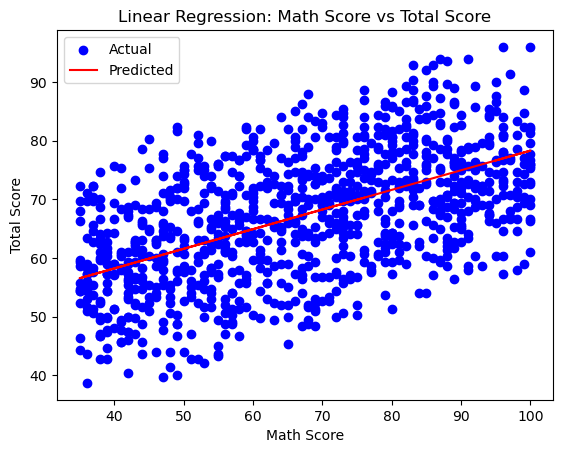

In [84]:
X = df[['Math_Score']]  # Independent variable
y = df['Total_Score']           # Target variable

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Math Score')
plt.ylabel('Total Score')
plt.title('Linear Regression: Math Score vs Total Score')
plt.legend()
plt.show()

Coefficient (Slope): 0.33468002981071104
Intercept: 44.886687918699636
MSE: 74.81127288641517
R2 Score: 0.37041119624033403


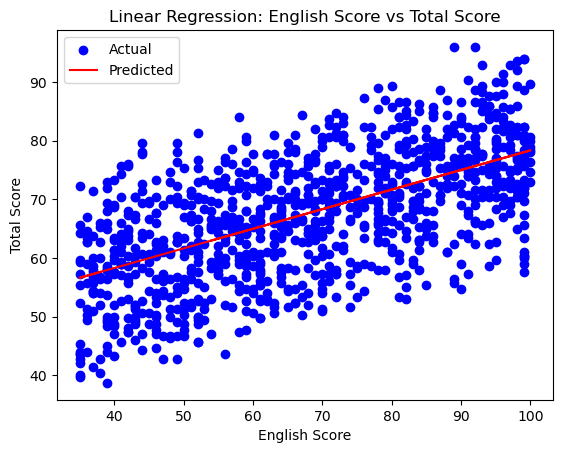

In [85]:
X = df[['English_Score']]  # Independent variable
y = df['Total_Score']           # Target variable

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('English Score')
plt.ylabel('Total Score')
plt.title('Linear Regression: English Score vs Total Score')
plt.legend()
plt.show()

Coefficient (Slope): 0.32660754946596304
Intercept: 45.71336951891587
MSE: 78.92170598398292
R2 Score: 0.3358190477982007


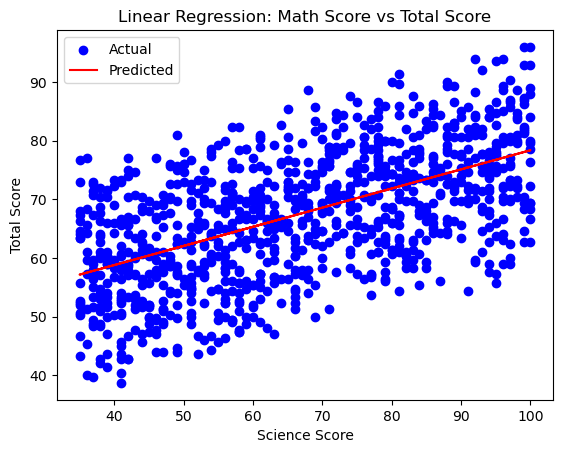

In [86]:
X = df[['Science_Score']]  # Independent variable
y = df['Total_Score']           # Target variable

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Science Score')
plt.ylabel('Total Score')
plt.title('Linear Regression: Math Score vs Total Score')
plt.legend()
plt.show()